Parte V: Exploración y Visualización de Datos Avanzada

En esta quinta parte del proyecto, vamos a expandir nuestro análisis exploratorio de datos (EDA) y visualización utilizando técnicas avanzadas. Aplicaremos todo lo que hemos aprendido hasta ahora, incluyendo cuadrículas, leyendas, anotaciones, flechas, y subplots, para obtener una comprensión más profunda de nuestro conjunto de datos de ventas.



Análisis y Predicción de Ventas en una Tienda de Retail (Core)
Parte III: Transformación y Análisis Avanzado de Datos con Pandas

En esta tercera parte del proyecto, continuaremos trabajando con el dataset de ventas que utilizamos en la Parte II. En esta fase, aplicaremos técnicas avanzadas de transformación y análisis de datos utilizando las nuevas habilidades adquiridas en Pandas, tales como agrupaciones complejas y el uso del método apply. Nos enfocaremos en extraer insights más profundos y preparar los datos para futuros análisis y modelos predictivos.

Proyecto I- Parte IV (Core)
Análisis y Predicción de Ventas en una Tienda de Retail

Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

Parte V

Instrucciones

Continuar desde la Parte IV

Asegúrate de tener el DataFrame df ya cargado y preparado desde la Parte IV.

Exploración de Datos Avanzada
- Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.
- Crea subplots para comparar diferentes variables clave.
Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.

- Generar un Tag en GitHub y Realizar una Presentación
Generar un Tag en GitHub: Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub, genera un Pull Request (PR) para revisión y finalmente crea un tag para esta versión del proyecto.

- Realizar una Presentación: Prepara una presentación en slides que resuma tu análisis y visualizaciones. La presentación debe incluir:
Introducción y objetivos del proyecto.
Descripción del conjunto de datos.
Principales análisis y hallazgos.
Visualizaciones clave con explicación.
Conclusiones y recomendaciones.
Utiliza herramientas como PowerPoint, Google Slides o cualquier otra aplicación de presentación.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd


data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/customer_shopping_data.csv')
data.head(10)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [ ]:
data.head(10)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
5,I227836,C657758,Female,28,Clothing,5,1500.40,Credit Card,24/05/2022,Forum Istanbul
6,I121056,C151197,Female,49,Cosmetics,1,40.66,Cash,13/03/2022,Istinye Park
7,I293112,C176086,Female,32,Clothing,2,600.16,Credit Card,13/01/2021,Mall of Istanbul
8,I293455,C159642,Male,69,Clothing,3,900.24,Credit Card,4/11/2021,Metrocity
9,I326945,C283361,Female,60,Clothing,2,600.16,Credit Card,22/08/2021,Kanyon


Transformación de Datos
Crea nuevas columnas:
- Basándonos en los datos existentes, crea nuevas columnas que sean útiles para el análisis.
- Por ejemplo, calcula el ingreso total por venta y normaliza las ventas.

In [4]:
data['Total_Sales_Revenue'] = data['quantity'] * data['price']
data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Total_Sales_Revenue
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,242.40


In [5]:
# Agrupacion de datos por categori y calcula el Total de Ventas por categoria
category_sales = data.groupby('category')['price'].sum()

# Crea el diccionario mapenado la categoria con la venta total.
category_sales_dict = category_sales.to_dict()

# Aplica normalizacion usando la fundion LAMBDA
data['Normalized_Sales'] = data.apply(lambda row: row['price'] / category_sales_dict[row['category']], axis=1)
print(data.head())


  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  Total_Sales_Revenue  \
0    Credit Card     5/8/2022          Kanyon              7502.00   
1     Debit Card   12/12/2021  Forum Istanbul              5401.53   
2           Cash    9/11/2021       Metrocity               300.08   
3    Credit Card   16/05/2021    Metropol AVM             15004.25   
4           Cash   24/10/2021          Kanyon               242.40   

   Normalized_Sales  
0          0.000048  
1          0.000099  
2          0.000010  
3          0.000165  
4          0.000267  


Clasifica los datos:
- Crea una columna que clasifique las ventas en categorías significativas
-  (e.g., ‘Alta’, ‘Media’, ‘Baja’).

In [6]:
# Definimos nuestro almacenamiento y etiqueta
bins = [0, 50, 100, float('inf')]  # Define the bin edges
labels = ['Low', 'Medium', 'High']  # Define the labels for each bin

# Apply pd.cut to create the new column
# Aplicamos pd.cut para crear la nueva columan  Sales_Category
data['Sales_Category'] = pd.cut(data['Total_Sales_Revenue'], bins=bins, labels=labels)


# Imprimimos el DataSet resultante
print(data.head(30))

   invoice_no customer_id  gender  age         category  quantity    price  \
0     I138884     C241288  Female   28         Clothing         5  1500.40   
1     I317333     C111565    Male   21            Shoes         3  1800.51   
2     I127801     C266599    Male   20         Clothing         1   300.08   
3     I173702     C988172  Female   66            Shoes         5  3000.85   
4     I337046     C189076  Female   53            Books         4    60.60   
5     I227836     C657758  Female   28         Clothing         5  1500.40   
6     I121056     C151197  Female   49        Cosmetics         1    40.66   
7     I293112     C176086  Female   32         Clothing         2   600.16   
8     I293455     C159642    Male   69         Clothing         3   900.24   
9     I326945     C283361  Female   60         Clothing         2   600.16   
10    I306368     C240286  Female   36  Food & Beverage         2    10.46   
11    I139207     C191708  Female   29            Books         

Agrupación y Agregación
- Agrupación por múltiples columnas:
- Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.

In [7]:
# Como nuestro DataSet no tiene tienda usamos el Shoppin_mall para tener las ventas por lugar

product_store_sales = data.groupby(['category', 'shopping_mall'])['Total_Sales_Revenue'].sum()
print(product_store_sales)

category  shopping_mall    
Books     Cevahir AVM           44541.00
          Emaar Square Mall     41995.80
          Forum Istanbul        42056.40
          Istinye Park          76083.30
          Kanyon               163029.15
                                 ...    
Toys      Mall of Istanbul     790522.88
          Metrocity            605946.88
          Metropol AVM         413306.88
          Viaport Outlet       199987.20
          Zorlu Center         197550.08
Name: Total_Sales_Revenue, Length: 80, dtype: float64


In [8]:
# Assuming your dataset has a 'Month' column (if not, you'll need to extract it from the 'InvoiceDate' column)
# Preparamos la columna InvoiceMonth para tener el mes de la venta
data['InvoiceMonth'] = pd.to_datetime(data['invoice_date'], format='%d/%m/%Y').dt.month
print(data.head())


# ya tenemos el mes ahora podemos calcular el total de ventas por esta columna

product_month_sales = data.groupby(['category', 'InvoiceMonth'])['Total_Sales_Revenue'].sum()
print(product_month_sales)


  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  Total_Sales_Revenue  \
0    Credit Card     5/8/2022          Kanyon              7502.00   
1     Debit Card   12/12/2021  Forum Istanbul              5401.53   
2           Cash    9/11/2021       Metrocity               300.08   
3    Credit Card   16/05/2021    Metropol AVM             15004.25   
4           Cash   24/10/2021          Kanyon               242.40   

   Normalized_Sales Sales_Category  InvoiceMonth  
0          0.000048           High             8  
1          0.000099           High            12  
2    

Aplicar funciones de agregación:
- Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.

In [9]:
# Calcular las estadisticas agrupados por  Categoria y totales de ventas por cada una
product_category_stats = data.groupby('category')['Total_Sales_Revenue'].agg(['sum', 'mean', 'count', 'min', 'max', 'std', 'var'])
print(product_category_stats)

# Interpretacion;
# La Categoria Technologia se presenta como la numero 1 en ventas en minimo y maximo.
# Se puede ver que en las Categorias en Tech, zapatos y ropas estan concentrados nuestras ventas.


                          sum          mean  count      min       max  \
category                                                                
Books            8.345529e+05    167.547260   4981    15.15    378.75   
Clothing         1.139968e+08   3305.500364  34487   300.08   7502.00   
Cosmetics        6.792863e+06    449.947864  15097    40.66   1016.50   
Food & Beverage  8.495351e+05     57.494251  14776     5.23    130.75   
Shoes            6.655345e+07   6632.793649  10034   600.17  15004.25   
Souvenir         6.358247e+05    127.190368   4999    11.73    293.25   
Technology       5.786235e+07  11581.735388   4996  1050.00  26250.00   
Toys             3.980426e+06    394.609521  10087    35.84    896.00   

                         std           var  
category                                    
Books             131.909394  1.740009e+04  
Clothing         2597.404620  6.746511e+06  
Cosmetics         351.873613  1.238150e+05  
Food & Beverage    45.385558  2.059849e+03  

Análisis Personalizado con apply
Función personalizada:
- Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.
- Ejemplo de uso avanzado: Calcula la desviación de cada venta respecto a la media de su grupo.

In [10]:
# Necesitamos agrupar los datos relevantes a la categoria (Ej. Categoria y Tienda)
# Agrupamos por Categoria y Transformamos - mean - calculando el mean de las ventas totales por cada grupo alienado a su fila correspondiente
group_means = data.groupby('category')['Total_Sales_Revenue'].transform('mean')
data['Deviation_From_Mean'] = data['Total_Sales_Revenue'] - group_means
print(data.head())

  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  Total_Sales_Revenue  \
0    Credit Card     5/8/2022          Kanyon              7502.00   
1     Debit Card   12/12/2021  Forum Istanbul              5401.53   
2           Cash    9/11/2021       Metrocity               300.08   
3    Credit Card   16/05/2021    Metropol AVM             15004.25   
4           Cash   24/10/2021          Kanyon               242.40   

   Normalized_Sales Sales_Category  InvoiceMonth  Deviation_From_Mean  
0          0.000048           High             8          4196.499636  
1          0.0

Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.



Instrucciones

Continuar desde la Parte III
Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.
Análisis Descriptivo y Visualización

- Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
- Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
- Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

Generar un Pull Request en GitHub
- Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.

In [12]:
# Calcula estadísticas descriptivas para todas las columnas numéricas
estadisticas_descriptivas = data.describe()

# Muestra los resultados
print(estadisticas_descriptivas)

# Se  calcula estadísticas para columnas específicas:
# Por ejemplo, para calcular la media de 'Total_Sales_Revenue':
media_ventas_totales = data['Total_Sales_Revenue'].mean()
print(f"Media de Ingresos Totales por Ventas: {media_ventas_totales}")

"""
Interpretacion
data.describe() proporciona un resumen de la tendencia central (media, mediana),
dispersión (desviación estándar, mínimo, máximo, cuartiles) y forma de la distribución para las columnas numéricas en tu DataFrame.
Calcular estadísticas para columnas específicas te da más control sobre el análisis.
"""


                age      quantity         price  Total_Sales_Revenue  \
count  99457.000000  99457.000000  99457.000000         99457.000000   
mean      43.427089      3.003429    689.256321          2528.789268   
std       14.990054      1.413025    941.184567          4222.475781   
min       18.000000      1.000000      5.230000             5.230000   
25%       30.000000      2.000000     45.450000           136.350000   
50%       43.000000      3.000000    203.300000           600.170000   
75%       56.000000      4.000000   1200.320000          2700.720000   
max       69.000000      5.000000   5250.000000         26250.000000   

       Normalized_Sales  InvoiceMonth  Deviation_From_Mean  
count      99457.000000  99457.000000         9.945700e+04  
mean           0.000080      6.113898         8.471559e-14  
std            0.000073      3.569511         3.034718e+03  
min            0.000010      1.000000        -1.053174e+04  
25%            0.000029      3.000000        -

'\nInterpretacion\ndata.describe() proporciona un resumen de la tendencia central (media, mediana),\ndispersión (desviación estándar, mínimo, máximo, cuartiles) y forma de la distribución para las columnas numéricas en tu DataFrame.\nCalcular estadísticas para columnas específicas te da más control sobre el análisis.\n'


Visualizar la Distribución con Histogramas y Boxplots:





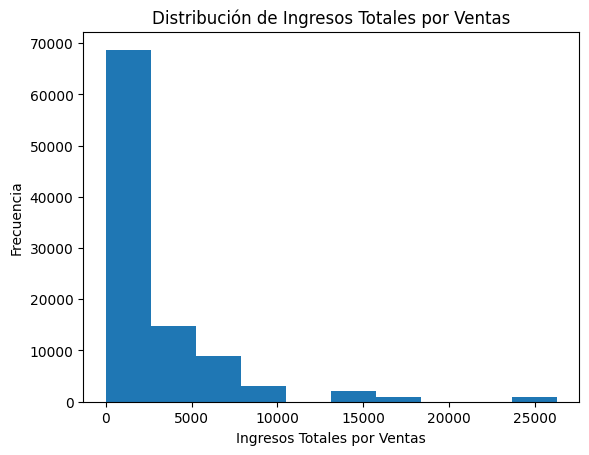

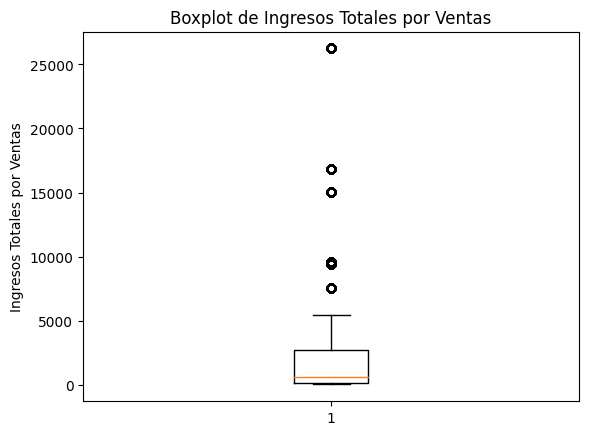

'\nInterpretacion\nHistogramas: Muestran la distribución de frecuencia de una variable numérica.\nTe ayudan a visualizar la forma de la distribución, identificar posibles valores atípicos y \ncomprender el rango de valores.\nBoxplots: Proporcionan un resumen visual de la distribución, incluyendo la mediana, cuartiles\ny posibles valores atípicos. Son especialmente útiles para comparar la distribución de una\nvariable en diferentes categorías.\n'

In [13]:
import matplotlib.pyplot as plt

# Crea un histograma para 'Total_Sales_Revenue'
plt.hist(data['Total_Sales_Revenue'], bins=10)  # Ajusta bins según sea necesario
plt.xlabel('Ingresos Totales por Ventas')
plt.ylabel('Frecuencia')
plt.title('Distribución de Ingresos Totales por Ventas')
#graba archivo con el grafico
plt.savefig('histograma_ingresos_totales.png')
plt.show()

# Crea un boxplot para 'Total_Sales_Revenue'
plt.boxplot(data['Total_Sales_Revenue'])
plt.ylabel('Ingresos Totales por Ventas')
plt.title('Boxplot de Ingresos Totales por Ventas')
#Graba archivo con el grafico
plt.savefig('boxplot_ingresos_totales.png')
plt.show()

"""
Interpretacion
Histogramas: Muestran la distribución de frecuencia de una variable numérica.
Te ayudan a visualizar la forma de la distribución, identificar posibles valores atípicos y
comprender el rango de valores.
Boxplots: Proporcionan un resumen visual de la distribución, incluyendo la mediana, cuartiles
y posibles valores atípicos. Son especialmente útiles para comparar la distribución de una
variable en diferentes categorías.
"""


Conclusion General:
- Al combinar estas técnicas, obtendrás una comprensión completa de las características y la distribución de tus datos.

Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo. Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.

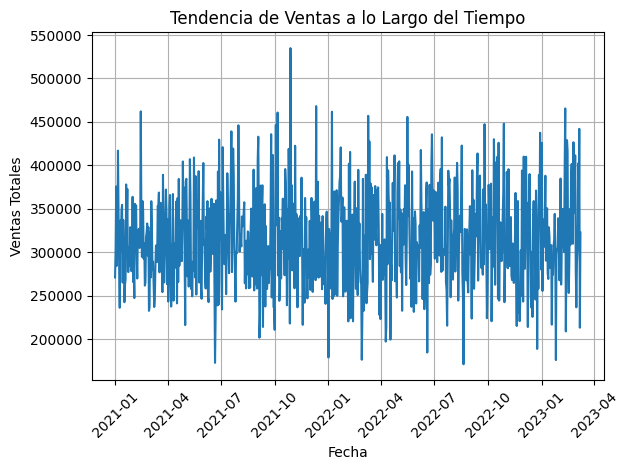

'\nInterpretacion\nAgrupamos los datos por fecha para obtener las ventas totales de cada día.\nUsamos plt.plot() para crear el gráfico de líneas, especificando la fecha en\nel eje x y las ventas totales en el eje y.\n'

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'InvoiceDate' es tu columna de fecha y 'Total_Sales_Revenue' es la columna de ventas:
# Primero, nos aseguramos de que 'InvoiceDate' esté en formato de fecha:
data['invoice_date'] = pd.to_datetime(data['invoice_date'], format='%d/%m/%Y')


# Agrupa las ventas por fecha y calcula la suma de ventas diarias:
ventas_por_fecha = data.groupby('invoice_date')['Total_Sales_Revenue'].sum().reset_index()


# Crea el gráfico de líneas:
plt.plot(ventas_por_fecha['invoice_date'], ventas_por_fecha['Total_Sales_Revenue'])
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.title('Tendencia de Ventas a lo Largo del Tiempo')
plt.grid(True)  # Agregamos una cuadrícula para mejor visualización
plt.xticks(rotation=45)  # Rota las etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustamos el diseño para evitar que las etiquetas se superpongan
#Graba archivo con el grafico
plt.savefig('tendencia_ventas_tiempo.png')
plt.show()

"""
Interpretacion
Agrupamos los datos por fecha para obtener las ventas totales de cada día.
Usamos plt.plot() para crear el gráfico de líneas, especificando la fecha en
el eje x y las ventas totales en el eje y.
"""

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Gráficos de dispersión para analizar relaciones:

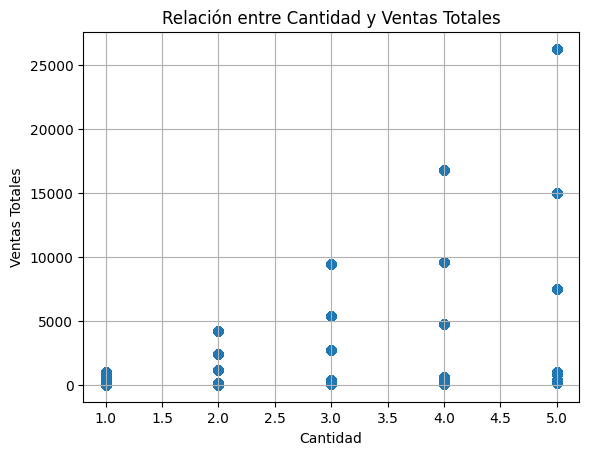

'\nInterpretacion\nplt.scatter() crea un gráfico de dispersión, donde cada punto representa\nuna observación en los datos.\nLa posición del punto en el gráfico está determinada por los valores de las\ndos variables que se están analizando.\n'

In [15]:
import matplotlib.pyplot as plt

# Ejemplo: Analizar la relación entre 'quantity' y 'Total_Sales_Revenue'
plt.scatter(data['quantity'], data['Total_Sales_Revenue'])
plt.xlabel('Cantidad')
plt.ylabel('Ventas Totales')
plt.title('Relación entre Cantidad y Ventas Totales')
plt.grid(True)
#Graba archivo con el grafico
plt.savefig('relacion_cantidad_ventas.png')
plt.show()

# Puedes cambiar las variables para analizar otras relaciones, por ejemplo:
# plt.scatter(data['price'], data['Total_Sales_Revenue']) # Relación entre precio y ventas totales

"""
Interpretacion
plt.scatter() crea un gráfico de dispersión, donde cada punto representa
una observación en los datos.
La posición del punto en el gráfico está determinada por los valores de las
dos variables que se están analizando.
"""

Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

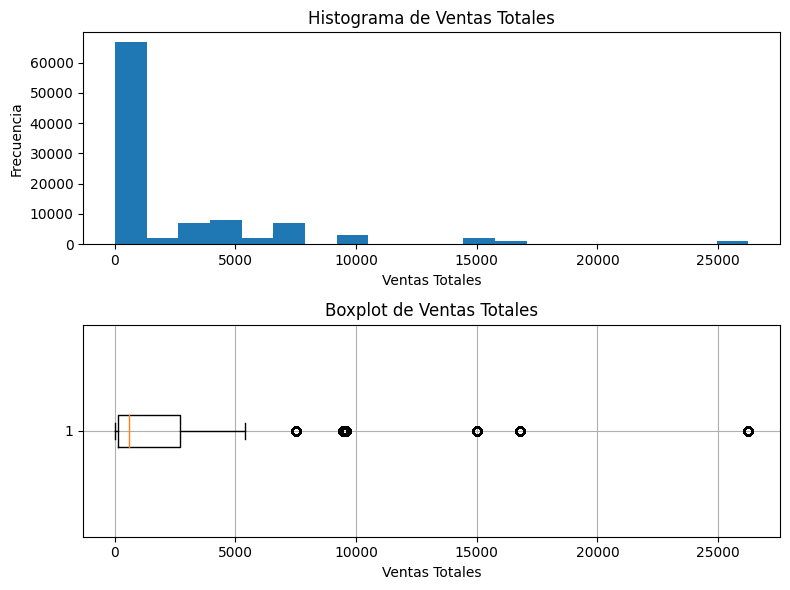

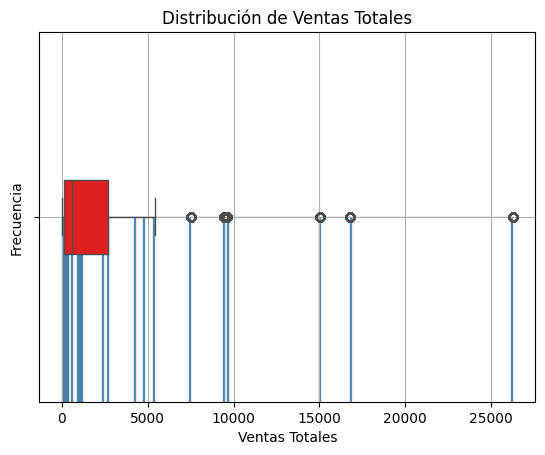

'\nInterpretacion\nSubplots de Matplotlib: Dividimos la figura en dos subplots para mostrar el\nhistograma y el boxplot por separado, pero en la misma figura.\nSeaborn: Superponemos el boxplot sobre el histograma para una visualización\nmás compacta.\nos valores atípicos se resaltan en el boxplot.\n\nDetectando valores atípicos:\n\nEn el histograma: Los valores atípicos suelen aparecer como barras aisladas en\nlos extremos de la distribución.\nEn el boxplot: Los valores atípicos se muestran como puntos individuales más\nallá de los "bigotes" del boxplot.\n'

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Usando subplots de Matplotlib:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))  # Crea dos subplots, uno encima del otro

# Histograma en el primer subplot:
ax1.hist(data['Total_Sales_Revenue'], bins=20)  # Ajusta 'bins' según sea necesario
ax1.set_xlabel('Ventas Totales')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Histograma de Ventas Totales')

# Boxplot en el segundo subplot:
ax2.boxplot(data['Total_Sales_Revenue'], vert=False)  # Boxplot horizontal
ax2.set_xlabel('Ventas Totales')
ax2.set_title('Boxplot de Ventas Totales')

plt.tight_layout()  # Ajusta el diseño para evitar superposiciones
plt.grid(True)  # Cuadrícula
#Graba archivo con el grafico
plt.savefig('histograma_boxplot_ventas.png')
plt.show()


# 2. Usando Seaborn:

# Crea un histograma con un boxplot superpuesto
sns.histplot(data['Total_Sales_Revenue'], kde=False)  # kde=False para quitar la curva de densidad
sns.boxplot(x=data['Total_Sales_Revenue'], showfliers=True,  # showfliers=True para mostrar valores atípicos
            color='red', width=0.2, boxprops={'zorder': 2})  # Personaliza el boxplot
plt.xlabel('Ventas Totales')
plt.ylabel('Frecuencia')
plt.title('Distribución de Ventas Totales')
plt.grid(True)  # Cuadrícula
#Graba archivo con el grafico
plt.savefig('distribución_de_ventas_totales.png')
plt.show()

"""
Interpretacion
Subplots de Matplotlib: Dividimos la figura en dos subplots para mostrar el
histograma y el boxplot por separado, pero en la misma figura.
Seaborn: Superponemos el boxplot sobre el histograma para una visualización
más compacta.
os valores atípicos se resaltan en el boxplot.

Detectando valores atípicos:

En el histograma: Los valores atípicos suelen aparecer como barras aisladas en
los extremos de la distribución.
En el boxplot: Los valores atípicos se muestran como puntos individuales más
allá de los "bigotes" del boxplot.
"""


Exploración de Datos Avanzada

Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.

Crea subplots para comparar diferentes variables clave. Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.

Generar un Tag en GitHub y Realizar una Presentación Generar un Tag en GitHub: Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub, genera un Pull Request (PR) para revisión y finalmente crea un tag para esta versión del proyecto.

Realizar una Presentación: Prepara una presentación en slides que resuma tu análisis y visualizaciones. La presentación debe incluir: Introducción y objetivos del proyecto. Descripción del conjunto de datos. Principales análisis y hallazgos. Visualizaciones clave con explicación. Conclusiones y recomendaciones. Utiliza herramientas como PowerPoint, Google Slides o cualquier otra aplicación de presentación.

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print(data.head())

# Asumiendo que tu DataFrame se llama 'data'
#matriz_correlacion = data.corr()

  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  Total_Sales_Revenue  \
0    Credit Card   2022-08-05          Kanyon              7502.00   
1     Debit Card   2021-12-12  Forum Istanbul              5401.53   
2           Cash   2021-11-09       Metrocity               300.08   
3    Credit Card   2021-05-16    Metropol AVM             15004.25   
4           Cash   2021-10-24          Kanyon               242.40   

   Normalized_Sales Sales_Category  InvoiceMonth  Deviation_From_Mean  
0          0.000048           High             8          4196.499636  
1          0.0

In [18]:
numeric_data = data.select_dtypes(include=['number'])
# solo las columnas que son numeros

In [19]:
correlation_matrix = numeric_data.corr()
#crea la correlacion

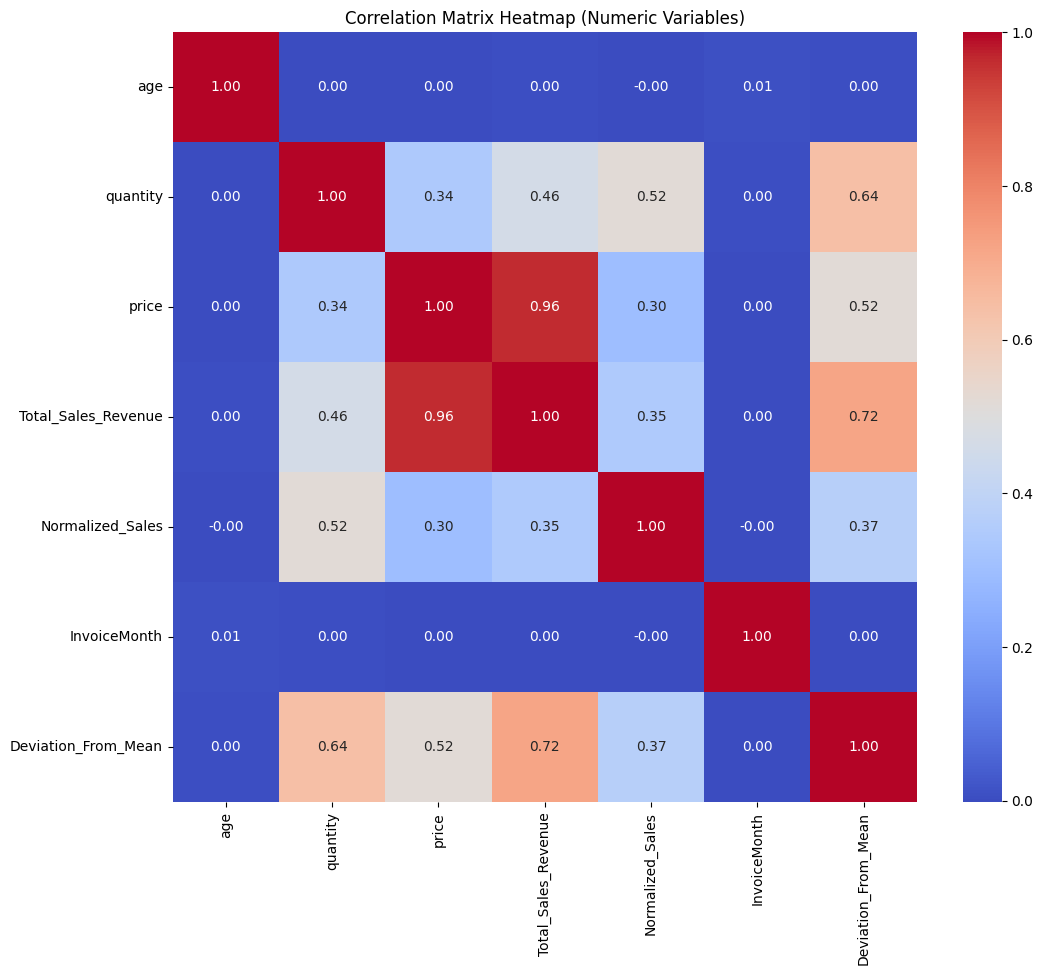

In [ ]:
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap (Numeric Variables)')
plt.savefig('correlation_heatmap.png')
#Grabar el grafico como PNG
plt.show()

Crea subplots para comparar diferentes variables clave. Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.

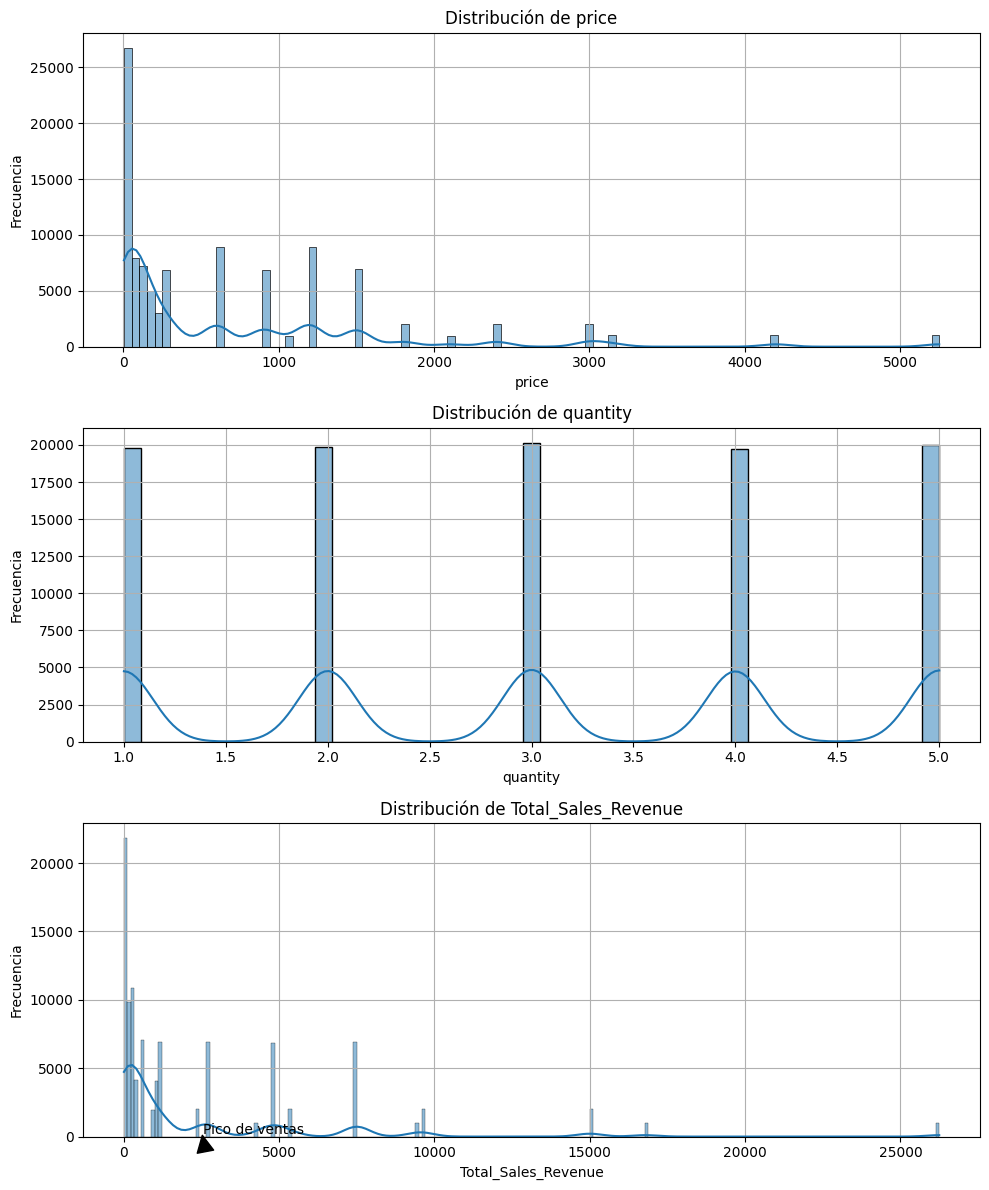

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecciona las variables clave que deseas comparar
variables_clave = ['price', 'quantity', 'Total_Sales_Revenue']

# Crea la figura y los subplots
fig, axes = plt.subplots(nrows=len(variables_clave), ncols=1, figsize=(10, 12))

# Itera sobre las variables clave y crea un subplot para cada una
for i, variable in enumerate(variables_clave):
    ax = axes[i]

    # Crea un histograma o gráfico de dispersión, según sea apropiado
    if variable in ['price', 'quantity', 'Total_Sales_Revenue']:
        sns.histplot(data[variable], ax=ax, kde=True)

    # Añade elementos para mejorar la claridad
    ax.set_title(f'Distribución de {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('Frecuencia')
    ax.grid(True)  # Cuadrícula

    # Añade anotaciones o flechas si es necesario
    if variable == 'Total_Sales_Revenue':
        ax.annotate('Pico de ventas', xy=(data[variable].mean(), 100),
                    xytext=(data[variable].mean() + 10, 200),
                    arrowprops=dict(facecolor='black', shrink=0.05))

# Ajusta el diseño y muestra la figura
plt.tight_layout()
# guarda en un archivo PNG
plt.savefig('comparacion_variables.png')
plt.show()

In [ ]:
plt.savefig('comparacion_variables.png')
# guarda en un archivo PNG

<Figure size 640x480 with 0 Axes>

Interpretaciones preliminares;
Sobre la distribución de las variables:

- price, quantity, Total_Sales_Revenue: Los histogramas de estas variables muestran que la mayoría de las ventas se concentran en valores bajos o medios.
- Hay algunos valores atípicos en 'Total_Sales_Revenue', lo que indica algunas ventas con ingresos significativamente más altos.
Correlación:
- El mapa de calor de la matriz de correlación muestra una correlación positiva entre 'quantity' y 'Total_Sales_Revenue', lo que es lógico, ya que a mayor cantidad de productos vendidos, mayores son los ingresos.
- También puede haber otras correlaciones entre variables que se pueden explorar con más detalle.

Sobre la tendencia de ventas:

- Tendencia a lo largo del tiempo: El gráfico de líneas de ventas a lo largo del tiempo podría revelar patrones o tendencias estacionales, como picos de ventas en ciertos meses o días. Se debe analizar con más detalle para identificar patrones específicos.
En general:

- Valores atípicos: Los valores atípicos en 'Total_Sales_Revenue' sugieren que hay algunas ventas que generan ingresos mucho más altos que la mayoría. Estos valores atípicos podrían ser investigados para comprender mejor las circunstancias que los generan.
Relaciones entre variables: El análisis de correlación y los gráficos de dispersión pueden ayudar a identificar relaciones entre diferentes variables, lo que podría ser útil para la toma de decisiones comerciales.
Patrones y tendencias: Un análisis más profundo de los datos y los gráficos podría revelar patrones y tendencias adicionales que no son inmediatamente evidentes, como la preferencia de los clientes por ciertos productos o categorías.

